In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
import pandas as pd
from scipy.io import arff
import statistics

In [2]:
# Logistic regression functions

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
    
        return cost.mean()

def gradient_descent(X, y, w_in, b_in, alpha, iterations):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        n = w_in.shape
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

def NSL_KDD_scale(X):
    stdevs = X.std(axis=0)
    stdevs = np.clip(stdevs, 1e-7, None)
    scaled_X = (X - X.mean(axis=0)) / stdevs
    #re-scale src and dst bytes with log scaling
    scaled_X[4:6] = np.log1p(X[4:6])
    return scaled_X

In [3]:
# Loads training and test data
# Creates a universal label encoder so test and train have common encodings
train_data, meta = arff.loadarff('KDDTrain+.arff')
test_data, test_meta = arff.loadarff('KDDTest+.arff')

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
        test_df[col] = test_df[col].str.decode('utf-8')
for col in ['protocol_type', 'service', 'flag', 'class']:
    le.fit(df[col])
    df[col] = le.transform(df[col])
    test_df[col] = le.transform(test_df[col])

# split training and test data into X and Y
train_X = df.iloc[:, :41].to_numpy(dtype=float)
train_y = df.iloc[:, 41].to_numpy(dtype=float)

test_X = test_df.iloc[:, :41].to_numpy(dtype=float)
test_y = test_df.iloc[:, 41].to_numpy(dtype=float)

scaled_train_X = NSL_KDD_scale(train_X)
scaled_test_X  = NSL_KDD_scale(test_X)

In [4]:
# init weights and biases...
w_in = np.random.random_sample(train_X[0].shape)
b_in = np.random.random_sample()
alpha = 0.1
iters = 2000

In [5]:
# Fit n-feature training data to model!
w,b,J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters)
print(f"New weights: {w}, new bias: {b}")

Iteration    0: Cost 0.9521590696361498
Iteration  200: Cost 0.17463327210728952
Iteration  400: Cost 0.14891516325126064
Iteration  600: Cost 0.13690849087097792
Iteration  800: Cost 0.13193723982521025
Iteration 1000: Cost 0.12892201256667624
Iteration 1200: Cost 0.12699750481695998
Iteration 1400: Cost 0.12560104532904565
Iteration 1600: Cost 0.12451042831859364
Iteration 1800: Cost 0.12361856031332977
New weights: [ 0.01513577  0.72337128 -0.02354319  0.60740459 -0.0766773  -0.00997736
  0.05843868 -0.70158276 -0.01314094 -0.615243   -0.03669848  0.25341665
  0.29371908 -0.09626336  0.12696265  0.48851814  0.35104951 -0.01231154
  0.11718812  0.74883945  0.28310641  0.44664393 -0.72588172 -0.10186258
  0.01220616 -0.40380126  0.14193385 -0.19232598  1.22140381  0.40002669
 -0.2114897  -0.55189115  1.17312144 -0.29887377 -0.21037337 -0.8887979
 -0.24623247 -0.61837376 -0.78788019 -0.14906918 -0.07203591], new bias: 0.06715335256057106


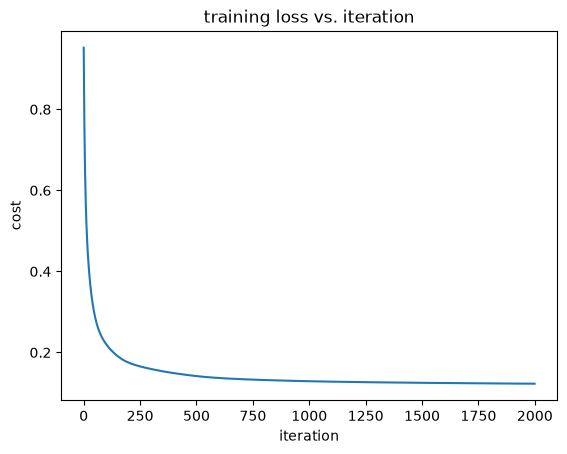

In [6]:
# plot cost vs. iterations
plt.plot(np.arange(len(J_history)), J_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("training loss vs. iteration")
plt.show()

In [7]:
# Training cost
preds = (sigmoid(scaled_train_X @ w + b) >= 0.5).astype(int)
print((preds == train_y).mean())

0.9541647813420336


In [8]:
# Test cost
preds = (sigmoid(scaled_test_X @ w + b) >= 0.5).astype(int)
print((preds == test_y).mean())

0.7802519517388219
